# Mental Health Support Chatbot: Semantic Intent Matching

A retrieval-based chatbot that matches a user's message to the closest known intent using sentence embeddings, then replies with a varied, supportive response.

**What this notebook does**
1. Loads and cleans `intents.json` (encoding bugs, placeholders, locale-specific content)
2. Builds two retrievers: a **TF-IDF baseline** and **Sentence-Transformers** embeddings (`paraphrase-MiniLM-L6-v2`)
3. **Evaluates** them (leave-one-out over patterns + a hand-written paraphrase test set)
4. Adds a **confidence threshold** with a fallback reply, tuned on data, including out-of-scope inputs
5. Adds a **crisis-safety layer** that runs before any retrieval
6. Provides a chat function with no immediate repeated replies

> **Not a medical tool.** This is a student NLP project. It does not replace a mental health professional.

## 1. Setup

In [3]:
import json, re, random
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score, classification_report

SEED = 42
random.seed(SEED); np.random.seed(SEED)

DATA_PATH = "intents.json"
AUTHOR = "Zeyad ElMorshedi"
# Crisis resources shown to the user. Verify these before deploying in a real setting.
LOCAL_HELPLINE = "Egypt's national psychological support hotline: 16328. For emergencies, call the ambulance on 123."

## 2. Load and clean the data

Issues found in the raw file: broken characters (mojibake), an empty pattern, a `>` placeholder in a reply, a hardcoded phone number from another country, and an India-specific statistic.

In [4]:
with open(DATA_PATH, encoding="utf-8") as f:
    raw = json.load(f)["intents"]

def fix_mojibake(s):
    """Repair text like 'Ã¢â‚¬â„¢' that was decoded with the wrong encoding."""
    try:
        s = s.encode("cp1252").decode("utf-8")
    except (UnicodeEncodeError, UnicodeDecodeError):
        pass
    return s.replace("\u2019", "'").replace("\u201c", '"').replace("\u201d", '"')

def clean(s):
    return re.sub(r"\s+", " ", fix_mojibake(s)).strip()

CRISIS_TAG = "suicide"
CRISIS_REPLY = ("I'm really sorry you're going through this, and I'm glad you told me. "
                "You don't have to face it alone. Please reach out to someone right now: a trusted person, "
                "a mental health professional, or emergency services. " + LOCAL_HELPLINE)

intents, fixed = {}, 0
for it in raw:
    tag = it["tag"]
    patterns = sorted({clean(p) for p in it["patterns"] if clean(p)})
    responses = [clean(r) for r in it["responses"] if clean(r)]
    before = list(responses)
    if tag == "creation":
        responses = [r.replace("created by >.", f"created by {AUTHOR} as an NLP project.") for r in responses]
    if tag == "mental-health-fact":
        responses = [r for r in responses if "Indians" not in r]   # drop locale-specific statistic
    if tag == CRISIS_TAG:
        responses = [CRISIS_REPLY]
    fixed += sum(a != b for a, b in zip(before, responses)) + abs(len(before) - len(responses))
    intents[tag] = {"patterns": patterns, "responses": responses}

print(f"{len(intents)} intents, {sum(len(v['patterns']) for v in intents.values())} patterns, {fixed} responses repaired/replaced")
assert not any("Ã" in r for v in intents.values() for r in v["responses"]), "encoding issue remains"

# Flat table used by the retrievers (the empty 'no-response' pattern was removed above)
corpus = pd.DataFrame([{"pattern": p, "tag": t} for t, v in intents.items() for p in v["patterns"]])
corpus.head()

80 intents, 231 patterns, 5 responses repaired/replaced


,pattern,tag
0,Bonjour,greeting
1,Guten tag,greeting
2,Hello,greeting
3,Hey,greeting
4,Hey there,greeting


## 3. Data overview

Most intents have only 1 to 3 example patterns, so evaluation has to be designed carefully (see section 5).

count    79.000000
mean      2.924051
min       1.000000
max      12.000000
Name: count, dtype: float64


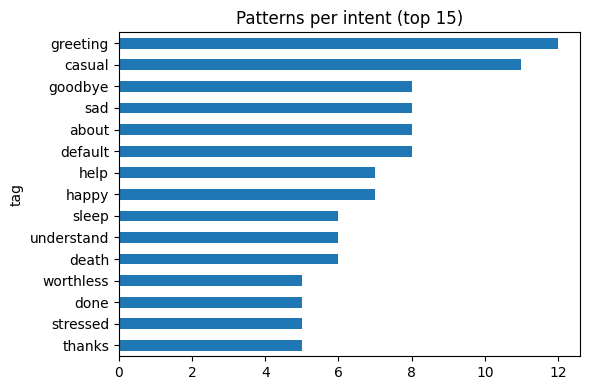

Intents with a single pattern: 32


In [5]:
counts = corpus["tag"].value_counts()
print(counts.describe()[["count", "mean", "min", "max"]])
counts.head(15).plot.barh(figsize=(6, 4), title="Patterns per intent (top 15)").invert_yaxis()
plt.tight_layout(); plt.show()
print("Intents with a single pattern:", int((counts == 1).sum()))

## 4. Retrievers

- **TF-IDF baseline**: character and word n-grams with cosine similarity.
- **MiniLM embeddings**: semantic similarity, so paraphrases with different words can still match.

If `sentence-transformers` can't be loaded (for example, no internet), the notebook falls back to the baseline so it still runs.

In [6]:
class Retriever:
    def __init__(self, name, encode):
        self.name, self.encode = name, encode
        self.matrix = encode(corpus["pattern"].tolist())
    def sims(self, texts):
        q = self.encode(texts)
        return np.asarray(q @ self.matrix.T)

def tfidf_backend():
    vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4), lowercase=True, sublinear_tf=True)
    vec.fit(corpus["pattern"])
    def encode(texts):
        m = vec.transform(texts)
        return m.toarray()
    return Retriever("TF-IDF (baseline)", encode)

def minilm_backend():
    from sentence_transformers import SentenceTransformer
    st = SentenceTransformer("paraphrase-MiniLM-L6-v2")
    def encode(texts):
        return st.encode(texts, normalize_embeddings=True, show_progress_bar=False)
    return Retriever("MiniLM embeddings", encode)

retrievers = {"tfidf": tfidf_backend()}
try:
    retrievers["minilm"] = minilm_backend()
except Exception as e:
    print("MiniLM unavailable, using TF-IDF only:", type(e).__name__)
print("Backends:", [r.name for r in retrievers.values()])

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.51k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Backends: ['TF-IDF (baseline)', 'MiniLM embeddings']


## 5. Evaluation

**A. Leave-one-out (LOO):** each pattern is used as a query against all *other* patterns; we check whether the predicted intent is correct. Only intents with 2+ patterns can be evaluated this way.

**B. Hand-written paraphrases:** new sentences that are not in the data, each labelled with the expected intent.

Accuracy alone can hide weak classes, so macro-F1 is reported too.

In [7]:
patterns, tags = corpus["pattern"].to_numpy(), corpus["tag"].to_numpy()
evaluable = corpus["tag"].map(counts).ge(2).to_numpy()

def loo_predictions(r):
    S = r.sims(patterns.tolist())
    same = patterns[:, None] == patterns[None, :]        # mask self and duplicate texts
    S = np.where(same, -1.0, S)
    idx = S.argmax(1)
    return tags[idx], S.max(1)

PARAPHRASES = [
 ("hello!", "greeting"), ("hey, is someone there", "greeting"), ("good bye", "goodbye"), ("see you tomorrow", "goodbye"),
 ("thanks a lot", "thanks"), ("i really appreciate it", "thanks"), ("i feel really lonely these days", "sad"),
 ("everything makes me so sad", "sad"), ("work is stressing me out", "stressed"), ("i feel like a failure", "worthless"),
 ("i cannot sleep at night", "sleep"), ("my grandfather passed away", "death"), ("i am nervous about everything", "anxious"),
 ("what's your name", "about"), ("who built you", "creation"), ("i feel awesome today", "happy"), ("i'm terrified", "scared"),
 ("can you help me", "help"), ("where do you live", "location"), ("tell me a funny joke", "jokes"),
 ("i have no friends at all", "friends"), ("i don't feel like talking", "not-talking"), ("what can you do for me", "skill"),
 ("i want to end my life", "suicide"), ("i need some advice", "user-advice"), ("what is the role of a therapist", "fact-6"),
 ("can mental illness be cured", "fact-26"), ("where can i find a support group", "fact-24"),
 ("what is depression", "fact-3"), ("i want to know more about mental health", "learn-mental-health"),
]
OUT_OF_SCOPE = ["what is the capital of France", "asdfghjkl", "how do i bake a cake", "who won the world cup",
                "explain quantum physics", "qwerty zxcv", "what's the price of bitcoin", "play some music",
                "how do i fix my car engine", "translate this into german"]

results = {}
for key, r in retrievers.items():
    loo_pred, loo_score = loo_predictions(r)
    m = evaluable
    S = r.sims([p for p, _ in PARAPHRASES]); pp = tags[S.argmax(1)]
    results[key] = dict(
        loo_acc=accuracy_score(tags[m], loo_pred[m]),
        loo_macro_f1=f1_score(tags[m], loo_pred[m], average="macro", zero_division=0),
        para_acc=np.mean(pp == np.array([t for _, t in PARAPHRASES])),
        loo_pred=loo_pred, loo_score=loo_score)
summary = pd.DataFrame({r.name: {"LOO accuracy": results[k]["loo_acc"], "LOO macro-F1": results[k]["loo_macro_f1"],
                                 "Paraphrase accuracy": results[k]["para_acc"]} for k, r in retrievers.items()}).T.round(3)
summary

,LOO accuracy,LOO macro-F1,Paraphrase accuracy
TF-IDF (baseline),0.563,0.539,0.600
MiniLM embeddings,0.698,0.655,0.867


In [8]:
main_key = "minilm" if "minilm" in retrievers else "tfidf"
main = retrievers[main_key]
print("Main model:", main.name)
wrong = pd.DataFrame({"pattern": patterns, "true": tags, "pred": results[main_key]["loo_pred"]})[evaluable]
print("\nSample of LOO errors (check which intents get confused):")
wrong[wrong.true != wrong.pred].head(10)

Main model: MiniLM embeddings

Sample of LOO errors (check which intents get confused):


,pattern,true,pred
1,Guten tag,greeting,name
9,Is anyone there?,greeting,location
10,Konnichiwa,greeting,casual
11,Ola,greeting,casual
19,Fare thee well,goodbye,greeting
21,Sayonara,goodbye,greeting
22,See you later,goodbye,casual
24,Than you very much,thanks,about
28,That's helpful,thanks,meditation
34,What should I call you?,about,wrong


## 6. Confidence threshold and fallback

The original version always returned the nearest intent, even for nonsense. Here a message is answered only if its best similarity is at least `THRESHOLD`; otherwise the bot asks the user to say more.

The threshold is chosen on the leave-one-out scores plus out-of-scope inputs, maximising: *correct answers accepted + out-of-scope inputs rejected*.

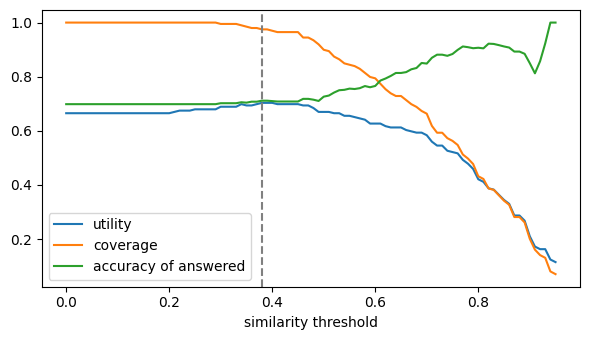

THRESHOLD = 0.38  | answered: 97% of in-scope | accuracy when answered: 71% | out-of-scope rejected: 90%


In [9]:
loo_score, loo_ok = results[main_key]["loo_score"][evaluable], (results[main_key]["loo_pred"] == tags)[evaluable]
oos_score = main.sims(OUT_OF_SCOPE).max(1)

grid = np.round(np.linspace(0.0, 0.95, 96), 2)
utility = [((loo_ok & (loo_score >= t)).sum() + (oos_score < t).sum()) / (len(loo_score) + len(oos_score)) for t in grid]
THRESHOLD = float(grid[int(np.argmax(utility))])

coverage = [(loo_score >= t).mean() for t in grid]
prec = [loo_ok[loo_score >= t].mean() if (loo_score >= t).any() else np.nan for t in grid]
plt.figure(figsize=(6, 3.5))
plt.plot(grid, utility, label="utility"); plt.plot(grid, coverage, label="coverage"); plt.plot(grid, prec, label="accuracy of answered")
plt.axvline(THRESHOLD, ls="--", c="gray"); plt.xlabel("similarity threshold"); plt.legend(); plt.tight_layout(); plt.show()

i = int(np.where(grid == THRESHOLD)[0][0])
print(f"THRESHOLD = {THRESHOLD}  | answered: {coverage[i]:.0%} of in-scope | accuracy when answered: {prec[i]:.0%} "
      f"| out-of-scope rejected: {(oos_score < THRESHOLD).mean():.0%}")

## 7. Crisis-safety layer

A rule-based check runs **before** retrieval, so messages about self-harm always get the crisis response, regardless of similarity scores. Retrieval alone could miss phrasings or match a wrong intent.

In [10]:
CRISIS_PATTERNS = [r"\bkill(ing)? myself\b", r"\bsuicid", r"\bend(ing)? (my|it all|my own) (life)?", r"\bwant(ed)? to die\b",
                   r"\bdon'?t want to (live|be alive|exist)\b", r"\bbetter off (dead|without me)\b", r"\bhurt(ing)? myself\b",
                   r"\bself[- ]?harm", r"\bcut(ting)? myself\b", r"\bno reason to live\b", r"\btake my own life\b"]
CRISIS_RE = re.compile("|".join(CRISIS_PATTERNS), re.IGNORECASE)

def is_crisis(text):
    return bool(CRISIS_RE.search(text))

tests = ["I want to kill myself", "sometimes i think everyone is better off without me", "I don't want to live anymore",
         "i'm so tired of this", "my exam killed me lol"]
for t in tests: print(f"{is_crisis(t)!s:>5}  {t}")

 True  I want to kill myself
 True  sometimes i think everyone is better off without me
 True  I don't want to live anymore
False  i'm so tired of this
False  my exam killed me lol


## 8. The chatbot

Per-session memory avoids repeating the same reply for an intent twice in a row.

In [11]:
FALLBACKS = ["I'm not sure I understood that. Could you tell me more about how you're feeling?",
             "I want to understand you better. Can you say that in a different way?",
             "I'm here to listen. What's been on your mind lately?"]
DISCLAIMER = "I'm a student project, not a substitute for a mental health professional."

class Chatbot:
    def __init__(self, retriever, threshold):
        self.r, self.threshold, self.last = retriever, threshold, {}
    def _pick(self, key, options):
        choices = [o for o in options if o != self.last.get(key)] or options
        reply = random.choice(choices); self.last[key] = reply
        return reply
    def respond(self, text):
        text = clean(text)
        if not text:
            return "empty", 1.0, self._pick("no-response", intents["no-response"]["responses"])
        if is_crisis(text):
            return CRISIS_TAG, 1.0, CRISIS_REPLY
        s = self.r.sims([text])[0]
        j = int(s.argmax()); score = float(s[j]); tag = corpus.loc[j, "tag"]
        if score < self.threshold:
            return "fallback", score, self._pick("fallback", FALLBACKS)
        return tag, score, self._pick(tag, intents[tag]["responses"])

bot = Chatbot(main, THRESHOLD)
print(DISCLAIMER, "\n")
demo = ["hi", "i feel really lonely these days", "work is stressing me out", "i can't sleep", "what is depression?",
        "asdfghjkl", "how do i bake a cake", "i want to kill myself", "thanks, bye"]
for u in demo:
    tag, score, reply = bot.respond(u)
    print(f"You: {u}\n[{tag} | {score:.2f}] Bot: {reply[:180]}\n")

I'm a student project, not a substitute for a mental health professional. 

You: hi
[greeting | 1.00] Bot: Hello there. Tell me how are you feeling today?

You: i feel really lonely these days
[sad | 0.90] Bot: I'm sorry to hear that. I'm here for you. Talking about it might help. So, tell me why do you think you're feeling this way?

You: work is stressing me out
[stressed | 0.69] Bot: Give yourself a break. Go easy on yourself.

You: i can't sleep
[sleep | 0.98] Bot: What do you think is the reason behind this?

You: what is depression?
[fact-3 | 1.00] Bot: A mental health disorder characterised by persistently depressed mood or loss of interest in activities, causing significant impairment in daily life.

You: asdfghjkl
[casual | 0.40] Bot: How were you feeling last week?

You: how do i bake a cake
[fallback | 0.36] Bot: I'm here to listen. What's been on your mind lately?

You: i want to kill myself
[suicide | 1.00] Bot: I'm really sorry you're going through this, and I'm glad you 

### Variety check
The same input repeated should not give the same reply twice in a row.

In [12]:
same_input = [bot.respond("i am so stressed")[2] for _ in range(6)]
print("No immediate repeats:", all(a != b for a, b in zip(same_input, same_input[1:])))

No immediate repeats: True


## 9. Interactive chat (command line)
Set `RUN_INTERACTIVE = True` and run the cell. Type `quit` to stop.

In [13]:
RUN_INTERACTIVE = False

def chat():
    print(DISCLAIMER + " Type 'quit' to exit.")
    while True:
        user = input("You: ")
        if user.strip().lower() in {"quit", "exit"}: break
        _, _, reply = bot.respond(user)
        print("Bot:", reply)

if RUN_INTERACTIVE:
    chat()

## 10. Limitations and next steps

- **Retrieval, not generation:** replies are pre-written; the bot cannot reason about new situations.
- **Small intent set:** many intents have 1 to 3 patterns, so near-identical intents (sad / depressed / worthless) can be confused. Leave-one-out and the hand-written set are small; treat the numbers as indicative, not definitive.
- **Threshold tuned on the same data it is evaluated on**, so the reported coverage is optimistic.
- **Crisis detection is keyword-based** and will miss indirect phrasing. A real system would need a trained classifier and clinical review.
- **Next steps:** fine-tune a classifier on a public emotion dataset (e.g. GoEmotions), compare it with this baseline using macro-F1, and add a Streamlit interface.